Initializing BGC-Argo Carbon Pump & Remineralization Pipeline...
Calculated AOU and Biogeochemical variables successfully!


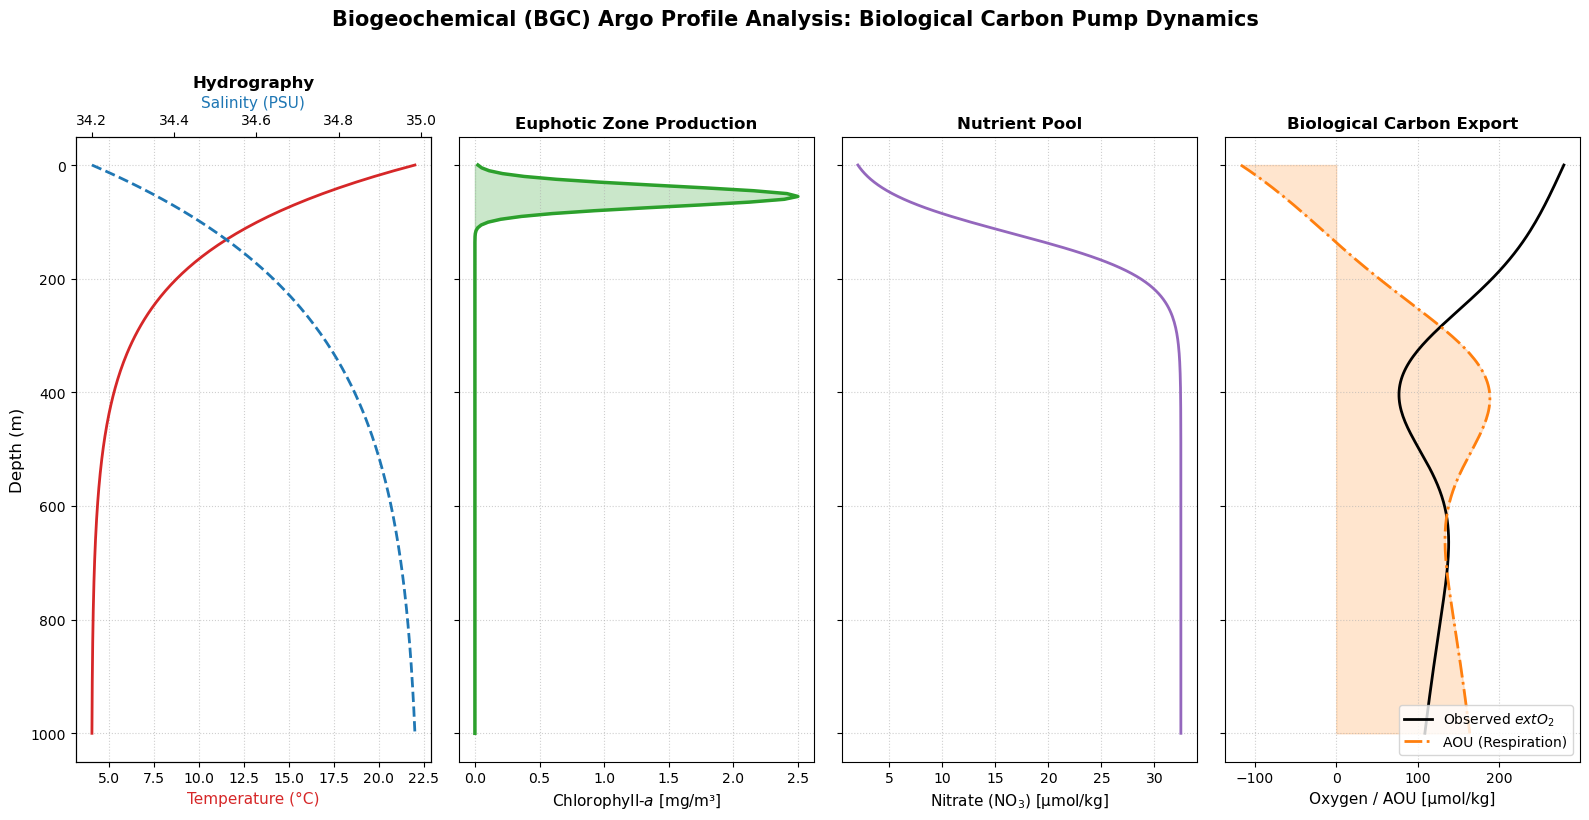

In [1]:
#Biogeochemical (BGC) Argo Profile Analysis: Biological Carbon Pump Dynamics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Initializing BGC-Argo Carbon Pump & Remineralization Pipeline...")

# 1. Simulating Vertical Depth Profile (0 to 1000 meters depth)
depth = np.linspace(0, 1000, 200) # meters (positive downwards)

# Temperature Profile (°C) - Thermocline structure
temp = 4.0 + 18.0 * np.exp(-depth / 150.0)

# Salinity Profile (PSU)
sal = 34.2 + 0.8 * (1.0 - np.exp(-depth / 250.0))

# Chlorophyll-a Profile (mg/m³) - Subsurface Chlorophyll Maximum (SCM) around 50m
chla = 2.5 * np.exp(-((depth - 55.0)**2) / (2 * 18.0**2))

# Nitrate Profile (µmol/kg) - Depleted at surface due to uptake, high at depth due to remineralization
nitrate = 32.0 / (1.0 + np.exp(-(depth - 120.0) / 40.0)) + 0.5

# Observed Dissolved Oxygen Profile (µmol/kg)
# High at surface, Minimum Zone (OMZ) at ~400m due to bacterial respiration
o2_obs = 240.0 * np.exp(-depth / 800.0) - 110.0 * np.exp(-((depth - 380.0)**2) / (2 * 120.0**2)) + 40.0

# 2. Computing Oxygen Saturation (O2_sat) & Apparent Oxygen Utilization (AOU)
# Garcia & Gordon (1992) simplified solubility equation approximation:
# O2_sat decreases with increasing temperature
o2_sat = 350.0 - (temp * 6.2) - (sal * 1.5)

# Apparent Oxygen Utilization: AOU = O2_sat - O2_obs
# Positive AOU indicates net respiration / organic matter decomposition
aou = o2_sat - o2_obs

# Creating Pandas DataFrame
bgc_df = pd.DataFrame({
    "depth": depth, "temp": temp, "sal": sal, 
    "chla": chla, "nitrate": nitrate, 
    "o2_obs": o2_obs, "o2_sat": o2_sat, "aou": aou
})

print("Calculated AOU and Biogeochemical variables successfully!")

# 3. Plotting Multi-Panel Vertical Profiles
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 8), sharey=True)

# Panel 1: Temperature & Salinity
ax1.plot(bgc_df["temp"], bgc_df["depth"], color="tab:red", label="Temp (°C)", linewidth=2)
ax1_sal = ax1.twiny()
ax1_sal.plot(bgc_df["sal"], bgc_df["depth"], color="tab:blue", linestyle="--", label="Salinity (PSU)", linewidth=2)
ax1.set_xlabel("Temperature (°C)", color="tab:red", fontsize=11)
ax1_sal.set_xlabel("Salinity (PSU)", color="tab:blue", fontsize=11)
ax1.set_ylabel("Depth (m)", fontsize=12)
ax1.set_title("Hydrography", fontsize=12, fontweight="bold")
ax1.grid(True, linestyle=":", alpha=0.6)

# Panel 2: Primary Production (Chlorophyll-a)
ax2.plot(bgc_df["chla"], bgc_df["depth"], color="tab:green", linewidth=2.5)
ax2.fill_betweenx(bgc_df["depth"], 0, bgc_df["chla"], color="tab:green", alpha=0.25)
ax2.set_xlabel(r"Chlorophyll-$a$ [mg/m³]", fontsize=11)
ax2.set_title("Euphotic Zone Production", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)

# Panel 3: Nutrients (Nitrate)
ax3.plot(bgc_df["nitrate"], bgc_df["depth"], color="tab:purple", linewidth=2)
ax3.set_xlabel(r"Nitrate ($\text{NO}_3$) [µmol/kg]", fontsize=11)
ax3.set_title("Nutrient Pool", fontsize=12, fontweight="bold")
ax3.grid(True, linestyle=":", alpha=0.6)

# Panel 4: Carbon Remineralization (AOU & Oxygen Minimum Zone)
ax4.plot(bgc_df["o2_obs"], bgc_df["depth"], color="black", label="Observed $\text{O}_2$", linewidth=2)
ax4.plot(bgc_df["aou"], bgc_df["depth"], color="tab:orange", linestyle="-.", label="AOU (Respiration)", linewidth=2)
ax4.fill_betweenx(bgc_df["depth"], 0, bgc_df["aou"], color="tab:orange", alpha=0.2)
ax4.set_xlabel(r"Oxygen / AOU [µmol/kg]", fontsize=11)
ax4.set_title("Biological Carbon Export", fontsize=12, fontweight="bold")
ax4.legend(loc="lower right", frameon=True)
ax4.grid(True, linestyle=":", alpha=0.6)

# Inverting Y-axis
plt.gca().invert_yaxis()

plt.suptitle("Biogeochemical (BGC) Argo Profile Analysis: Biological Carbon Pump Dynamics", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()

# Save Figure
plt.savefig("../figures/bgc_argo_remineralization.png", dpi=300, bbox_inches="tight")
plt.show()